In [15]:
if(!require(NbClust)){
  install.packages("NbClust");library(NbClust)
}

if(!require(rcdk)){
  install.packages("rcdk")
  library(rcdk)
}
if(!require(fingerprint)){
  install.packages("fingerprint")
  library(fingerprint)
}
# if(!require(dummies)){
#   install.packages("dummies")
#   library(dummies)
# }
if(!require(fastDummies)){
  install.packages("fastDummies")
  library(fastDummies)
}

[1] 0.306982

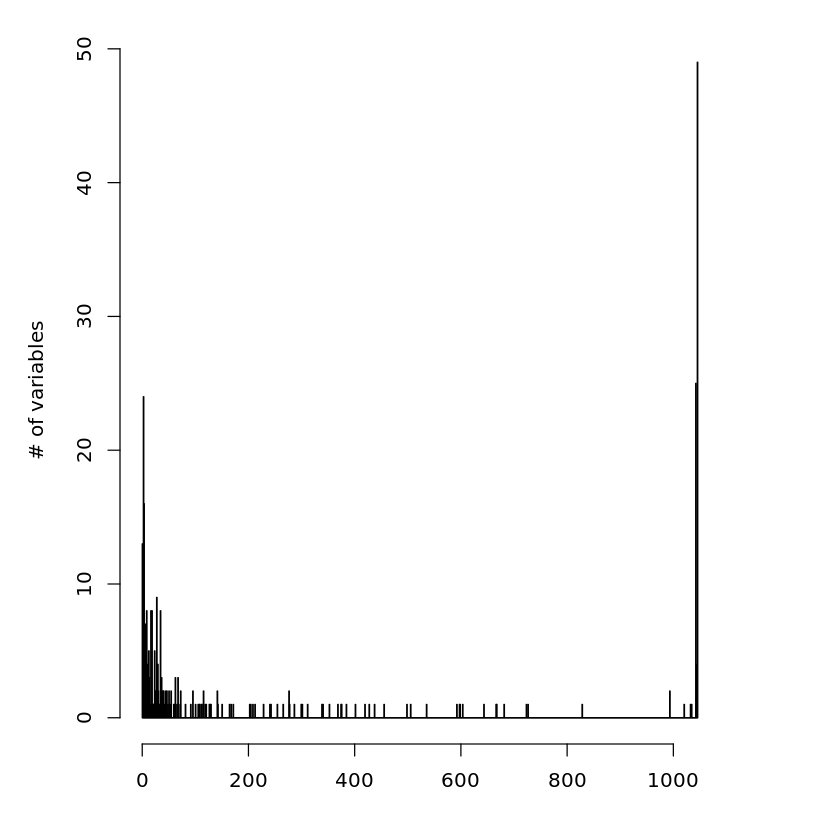

[1] 1046   17

integer(0)

integer(0)

integer(0)

integer(0)

...

[1] 1046  166

[1] 1046  166

[1] 1046  166

[1] 1046  166

[1] 1046  166

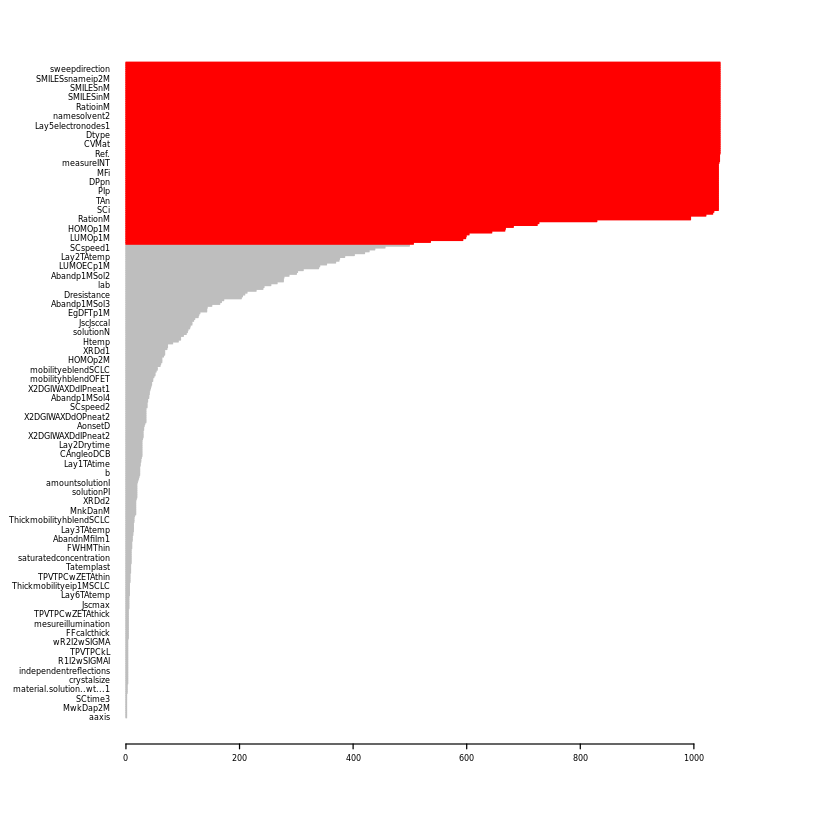

In [16]:
ifname<-"Data20211217Final.csv"
ifdata<-read.csv(ifname,row.names=1,header=TRUE,
                  as.is=TRUE,strip.white=TRUE)
NS<-dim(ifdata)[1]
NF<-dim(ifdata)[2]
#[1]NA check
vnaTF<-!is.na(ifdata)
nonNA<-sum(vnaTF)
nonNA/(NS*NF)

#[2] hist. of sample counts for all variables ----
vnonNAsum<-apply(vnaTF,2,sum)
MAX<-max(vnonNAsum)
par(cex=1.0)
par(mai=c(0.8,1,0.3,1))
hist(vnonNAsum,breaks=seq(0,MAX,1),main="",xlab="",ylab="# of variables")

#[3] barplot of sample counts for variables
nvariable<-dim(ifdata)[2]
sortdata<-sort(vnonNAsum,decreasing = FALSE)
sMAX<-max(sortdata)
pst<-paste("DataSort",ifname)
TF<-(sortdata>499)
selnames<-names(TF[TF==TRUE])
reddata<-rep("red",sum(TF))
graydata<-rep("gray",nvariable-sum(TF))
colc<-c(graydata,reddata)
par(cex=0.4)
barplot(sortdata,las=1, horiz=T,col=colc,border=colc)
Max500<-sortdata[TF]
#output
write.csv(Max500,"DataSampleCount500.csv")
MAX500final<-ifdata[,selnames]
write.csv(MAX500final,"DataMAX500final.csv")



#[1]Add Chemicals(SMILES) INDEX Data (Dummy Variables)
#SDataSet1<-read.delim("Data20211208Final.csv",sep=",",row.names=1,header=TRUE)
SDataSet1<-read.delim("Data20211217Final.csv",sep=",",row.names=1,header=TRUE)
SMILESnames<-c("SMILESinM","SMILESip1M","SMILESip2M","SMILESp2M","SMILESnM","SMILESp1M")
SMILESvariables<-SDataSet1[,c(SMILESnames)]
Objvariablesname<-c("Jsc","Voc","FF","PCEmax")
ObjV<-SDataSet1[,c(Objvariablesname)] 
basicvariableneames<-c("Egoptp1M","HOMOp1M","LUMOp1M","Mmonomerp1M","MnkDap1M","MwkDap1M","PDIp1M")
basicvariables<-SDataSet1[,c(basicvariableneames)] 
dnames<-c("Lay1Mname","Lay2Mname","Lay5electronodes1",
          "Lay6electronodes2","Additivesname",
          "namessolvent1","namessolvent2")
dumdata<-SDataSet1[,c(dnames)]
DUM <- dummy_cols(dumdata, remove_first_dummy = TRUE, remove_selected_columns = TRUE)

#[2]Non dummy Variables
#SDataSet2<-read.delim("DataMAX500final.csv",sep=",",row.names=1,header=TRUE)
SDataSet2<-read.delim("DataMAX500final.csv",sep=",",row.names=1,header=TRUE)
MX500data<-colnames(SDataSet2)
nonDumnames <- setdiff(MX500data, dnames)

Nondum00<-SDataSet2[,c(nonDumnames)]
delnames<-c(SMILESnames,Objvariablesname,basicvariableneames,dnames)

Nondum01<-Nondum00[, -which (colnames(Nondum00) %in% c(delnames))] 

Alldata <- data.frame(ObjV, basicvariables, SMILESvariables)

#[3]Merge data
#Alldata<-na.omit(data.frame(ObjV,basicvariables,SMILESvariables))
#Alldata<-data.frame(ObjV,basicvariables,SMILESvariables)
#write.csv(Alldata, file = "DataMerge20211208oh.csv", fileEncoding = "CP932")
write.csv(Alldata, file = "DataMerge202112120oh.csv")

dim(Alldata)


name_rmol11<-c("SMILESinM")
rmol11<-Alldata[, which (colnames(Alldata)%in%name_rmol11)]
name_rmol12<-c("SMILESip1M")
rmol12<-Alldata[, which (colnames(Alldata)%in%name_rmol12)]
name_rmol13<-c("SMILESip2M")
rmol13<-Alldata[, which (colnames(Alldata)%in%name_rmol13)]
name_rmol14<-c("SMILESnM")
rmol14<-Alldata[, which (colnames(Alldata)%in%name_rmol14)]
name_rmol15<-c("SMILESp1M")
rmol15<-Alldata[, which (colnames(Alldata)%in%name_rmol15)]
name_rmol16<-c("SMILESp2M")
rmol16<-Alldata[, which (colnames(Alldata)%in%name_rmol16)]


#mol11 <- parse.smiles(rmol11,kekulise  =  FALSE,omit.nulls  =  TRUE)
#mol12 <- parse.smiles(rmol12,kekulise  =  FALSE,omit.nulls  =  TRUE)
#mol13 <- parse.smiles(rmol13,kekulise  =  FALSE,omit.nulls  =  TRUE)
#mol14 <- parse.smiles(rmol14,kekulise  =  FALSE,omit.nulls  =  TRUE)
#mol15 <- parse.smiles(rmol15,kekulise  =  FALSE,omit.nulls  =  TRUE)
#mol16 <- parse.smiles(rmol16,kekulise  =  FALSE,omit.nulls  =  TRUE)


#mol11 <- parse.smiles(rmol11,kekulise  =  FALSE)
#mol12 <- parse.smiles(rmol12,kekulise  =  FALSE)
#mol13 <- parse.smiles(rmol13,kekulise  =  FALSE)
#mol14 <- parse.smiles(rmol14,kekulise  =  FALSE)
#mol15 <- parse.smiles(rmol15,kekulise  =  FALSE)
#mol16 <- parse.smiles(rmol16,kekulise  =  FALSE)

mol11 <- parse.smiles(rmol11)
mol12 <- parse.smiles(rmol12)
mol13 <- parse.smiles(rmol13)
mol14 <- parse.smiles(rmol14)
mol15 <- parse.smiles(rmol15)
mol16 <- parse.smiles(rmol16)



names(mol11) <- NULL
fuga11 <- sapply(mol11, is.null)
which(fuga11)

names(mol12) <- NULL
fuga12 <- sapply(mol12, is.null)
which(fuga12)

names(mol13) <- NULL
fuga13 <- sapply(mol13, is.null)
which(fuga13)


names(mol14) <- NULL
fuga14 <- sapply(mol14, is.null)
which(fuga14)

names(mol15) <- NULL
fuga15 <- sapply(mol15, is.null)
which(fuga15)

names(mol16) <- NULL
fuga16 <- sapply(mol16, is.null)
which(fuga16)



SMILES_Type<-c("maccs")

fps11<-lapply(mol11,get.fingerprint,type=SMILES_Type)
bitmatrix11<-fp.to.matrix(fps11)
dim(bitmatrix11)
dfp11<-data.frame(bitmatrix11)
fps12<-lapply(mol12,get.fingerprint,type=SMILES_Type)
bitmatrix12<-fp.to.matrix(fps12)
dim(bitmatrix12)
dfp12<-data.frame(bitmatrix12)
fps13<-lapply(mol13,get.fingerprint,type=SMILES_Type)
bitmatrix13<-fp.to.matrix(fps13)
dim(bitmatrix13)
dfp13<-data.frame(bitmatrix13)
fps14<-lapply(mol14,get.fingerprint,type=SMILES_Type)
bitmatrix14<-fp.to.matrix(fps14)
dim(bitmatrix14)
dfp14<-data.frame(bitmatrix14)
fps15<-lapply(mol15,get.fingerprint,type=SMILES_Type)
bitmatrix15<-fp.to.matrix(fps15)
dim(bitmatrix15)
dfp15<-data.frame(bitmatrix15)
fps16<-lapply(mol16,get.fingerprint,type=SMILES_Type)
bitmatrix16<-fp.to.matrix(fps16)
dim(bitmatrix16)
dfp16<-data.frame(bitmatrix16)

#name_rmol11<-c("RatioinM")
#rmol11<-data.frame(fmatrix13[, which (colnames(fmatrix13)%in%name_rmol11)])
#name_rmol12<-c("Ratioip1M")
#rmol12<-data.frame(fmatrix13[, which (colnames(fmatrix13)%in%name_rmol12)])
#name_rmol13<-c("Ratioip2M")
#rmol13<-data.frame(fmatrix13[, which (colnames(fmatrix13)%in%name_rmol13)])
#name_rmol14<-c("RationM")
#rmol14<-data.frame(fmatrix13[, which (colnames(fmatrix13)%in%name_rmol14)])
#name_rmol15<-c("Ratiop1M")
#rmol15<-data.frame(fmatrix13[, which (colnames(fmatrix13)%in%name_rmol15)])
#name_rmol16<-c("Ratiop2M")
#rmol16<-data.frame(fmatrix13[, which (colnames(fmatrix13)%in%name_rmol16)])



br11<-dfp11#*rmol11[,1]
br12<-dfp12#*rmol12[,1]
br13<-dfp13#*rmol13[,1]
br14<-dfp14#*rmol14[,1]
br15<-dfp15#*rmol15[,1]
br16<-dfp16#*rmol16[,1]

columnList11<-c("PCEave","PCEcal","PCEdiff","SMILESinM","SMILESip1M","SMILESip2M","SMILESnM","SMILESp1M","SMILESp2M","Jsc","Voc","FF","PCEmax","Lay1Mname","Lay2Mname","Lay5electronodes1",
          "Lay6electronodes2","Additivesname",
          "namessolvent1","namessolvent2")



mm <- sapply(MAX500final, function(xx){class(xx) != "character"})

#クラスがキャラクターの変数(aa)とそれ以外(cc)の変数に分類


cc<-data.frame(MAX500final[,mm]) 


fmatrix13<-data.frame(ObjV,cc[, -which (colnames(cc)%in%columnList11)],DUM,br11,br12,br13,br14,br15,br16)




In [17]:

tt01<-which(apply(fmatrix13,2,sd)==0)
length(tt01)
if (length(tt01)>0){
    dataUsed01<-fmatrix13[,-tt01]
 }else{ dataUsed01<-fmatrix13
}
ifname0<-"Mice_FPxRatio.togodata.csv"
write.csv(dataUsed01,"Mice_FPxRatio.togodata.csv")

listVar<-c("Jsc","Voc","FF","PCE")
NumVar<-length(listVar)

[1] 648

In [18]:
nf1<-dim(dataUsed01)[2]
charaCheck<-rep(FALSE,nf1)

In [19]:
dataUsed01
readData<-dataUsed01
dim(dataUsed01)

,Jsc,Voc,FF,PCEmax,Lay2thickness,Aonsetp1Mfilm,MwkDap1M,LUMOp1M,MnkDap1M,VolRatioS1,...,X153.5,X154.5,X155.5,X157.5,X159.5,X160.5,X162.5,X163.5,X164.5,X165.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.88,0.03,0.250,0.0066,30,700,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
2,1.22,0.08,0.250,0.0240,30,700,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
3,0.71,0.16,0.250,0.0280,30,700,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
4,1.14,0.36,0.400,0.1600,30,700,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
5,0.80,0.52,0.590,0.2500,30,NA,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
6,1.91,0.61,0.640,0.7400,30,NA,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
7,1.56,0.53,0.530,0.4400,30,NA,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
8,2.08,0.49,0.530,0.5300,30,NA,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0
9,3.46,0.67,0.660,1.5400,30,NA,NA,NA,NA,NA,...,0,0,0,0,0,0,0,0,0,0


[1] 1046  443

Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"
Warning message in cmdscale(ddata, k = 360, eig = TRUE):
"only 325 of the first 360 eigenvalues are > 0"


Number_clusters     Value_Index 
        30.0000          0.3205

[1] "points" "eig"    "x"      "ac"     "GOF"

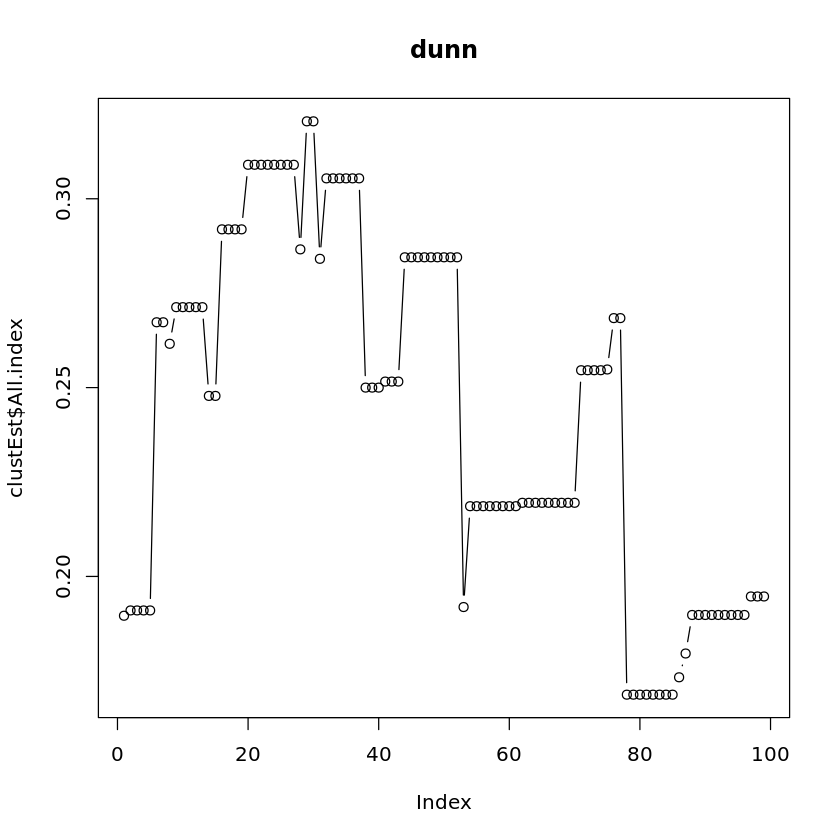

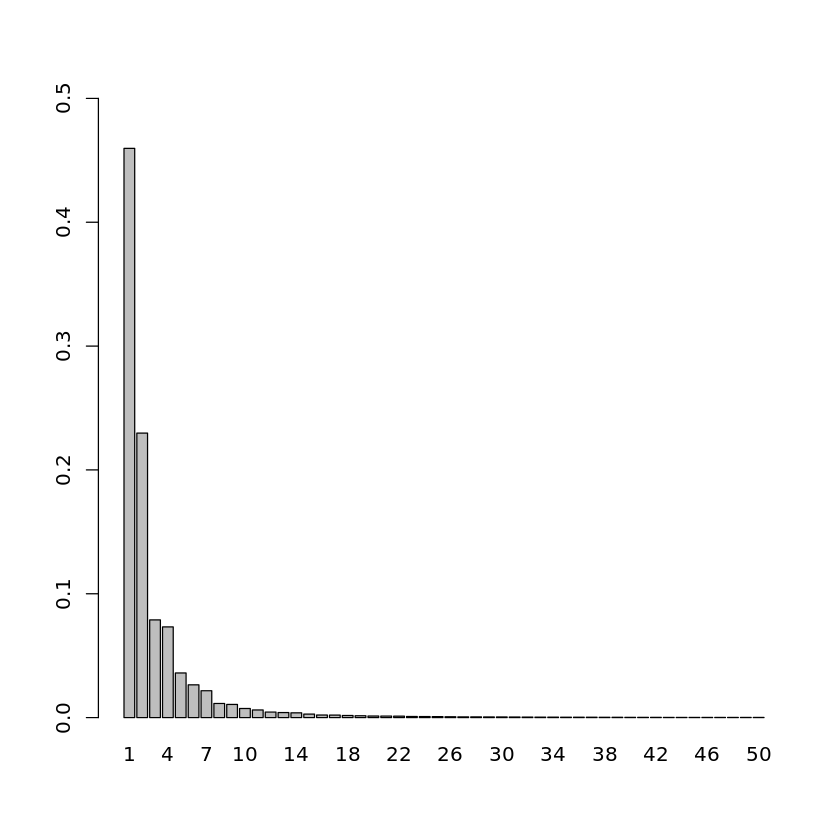

pdf 
  2

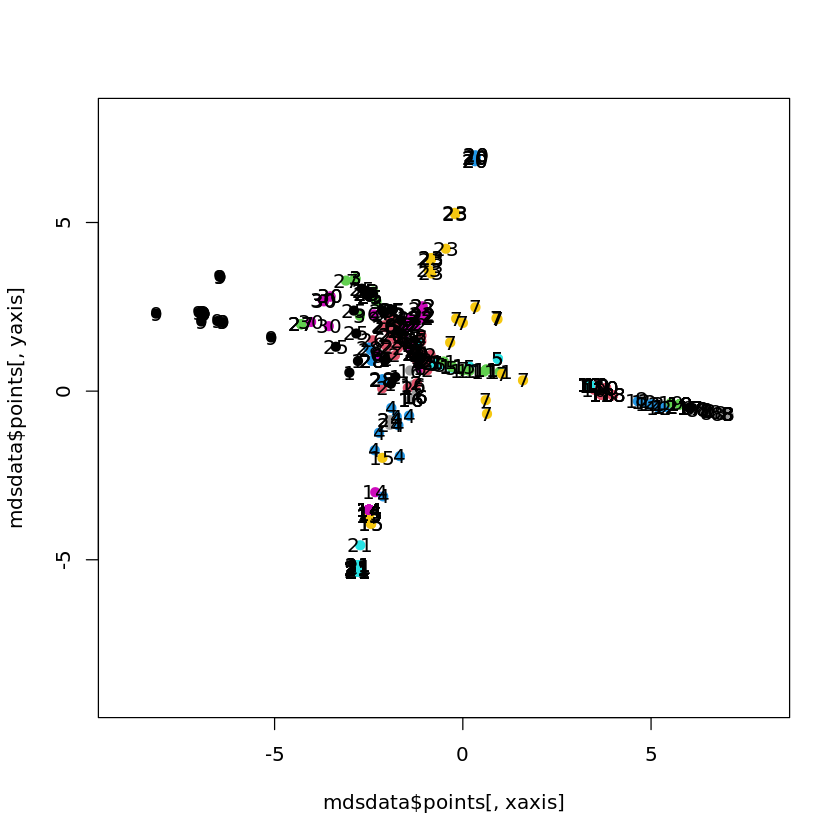

In [20]:

#[1]
for(i in 1:nf1){
  charaCheck[i]<-!is.character(readData[,i])
}
numData<-readData[,charaCheck]
corData<-cor(numData,use="pairwise.complete.obs")
corData[is.na(corData)==TRUE]<-0
ddata<-dist(1-corData)
#[2]
NF<-dim(corData)[2]
mdsdata<-cmdscale(ddata,k=360,eig=TRUE)
cindex<-c("dunn")
clustEst<-NbClust(data = mdsdata$points, diss = NULL, distance = "euclidean", min.nc = 2, max.nc = 100, 
            method = "ward.D2", index = cindex)  #ch  duda
clustEst$Best.nc
plot(clustEst$All.index,type="b",main=cindex)
classData<-clustEst$Best.partition
grpname <- as.factor(classData) 
names(mdsdata)
#[2a]peigen: percent eigen----------------
totaleigen<-sum(mdsdata$eig)
peigen<-mdsdata$eig/totaleigen
neigen<-length(mdsdata$eig)
barplot(peigen[1:50],names.arg=1:50,neigen,ylim=c(0,0.5))
#[2b]-------------------------------------
xaxis<-1
yaxis<-2
par(mfrow=c(1,1))
par(cex=1)
#[2c]
maxiv<-max(c(mdsdata$points[,xaxis],mdsdata$points[,yaxis]))
miniv<-min(c(mdsdata$points[,xaxis],mdsdata$points[,yaxis]))
ivdata<-c(as.integer(miniv)-1,as.integer(maxiv)+1)
s01 <- paste("DataGrp",cindex,".pdf")
plot(mdsdata$points[,xaxis],mdsdata$points[,yaxis],col=grpname,pch=19, cex=1,xlim=ivdata,ylim=ivdata)
text(mdsdata$points[,xaxis],mdsdata$points[,yaxis],labels=grpname)
fn<-paste0("DataGrp",cindex,".csv")
pdf(s01)
plot(mdsdata$points[,xaxis],mdsdata$points[,yaxis],col=grpname,pch=19, cex=1,xlim=ivdata,ylim=ivdata)
text(mdsdata$points[,xaxis],mdsdata$points[,yaxis],labels=grpname)
fn<-paste0("DataGrp",cindex,".csv")
write.csv(grpname,file=fn)

dev.off()